# SmartGrid CLI Demo Notebook

Ce notebook est **CLI-first** :

- il n'implémente pas la logique métier de training/predict/replay dans le notebook ;
- il appelle les **scripts officiels du repo** ;
- il charge ensuite les **artefacts générés** pour faire :
  - le classement des modèles,
  - l'analyse détaillée,
  - les graphes de démo.

## Hiérarchie officielle

- **Benchmark officiel métier** : replay strict day-ahead
- **Benchmark secondaire** : offline test split (diagnostic)
- **Predict target day** : vérification de la chaîne runtime sur une date
- **Promotion** : uniquement à partir du replay officiel

## Hypothèse
Ce notebook doit être exécuté **à la racine du repo SmartGrid**.


In [33]:
from __future__ import annotations

import json
import math
import os
import re
import shlex
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Makefile").exists() and (candidate / "scripts" / "train_consumption.py").exists():
            return candidate
    raise RuntimeError(
        f"Impossible de trouver la racine du repo SmartGrid depuis {start}. "
        "Lance le notebook depuis le repo ou fixe REPO_ROOT manuellement."
    )


# Option 1 : auto-détection
ROOT = find_repo_root(Path.cwd())

# Option 2 : fixe manuellement si besoin
# ROOT = Path('/chemin/vers/SmartGrid').resolve()

ARTIFACTS = ROOT / "artifacts"
CONFIG_DIR = ROOT / "configs" / "consumption"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)



print("ROOT:", ROOT)
print("ARTIFACTS:", ARTIFACTS)
print("CONFIG_DIR:", CONFIG_DIR)
print("Makefile exists:", (ROOT / "Makefile").exists())
print("train script exists:", (ROOT / "scripts" / "train_consumption.py").exists())

ROOT: /home/khalid/cours/m1/SmartGrid_Project/smart-grid
ARTIFACTS: /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts
CONFIG_DIR: /home/khalid/cours/m1/SmartGrid_Project/smart-grid/configs/consumption
Makefile exists: True
train script exists: True


## Configuration

In [28]:
# ---- Modes d'exécution
RUN_TRAINING = True
RUN_REPLAY = True
RUN_PREDICT = True
RUN_PROMOTE = True

# ---- Scope officiel
ONLY_STRICT_DAY_AHEAD = True

# ---- Fenêtre replay officielle
REPLAY_START_DATE = "2025-11-01"
REPLAY_END_DATE = "2025-11-31"

# ---- Date de démo / predict
TARGET_DATE = "2025-011-20"

# ---- Datasets / fichiers (laisser None pour utiliser les valeurs par défaut du repo)
DATASET_KEY = "full_2020_2026"
HISTORICAL_CSV = None
WEATHER_CSV = None
HOLIDAYS_XLSX = None
BENCHMARK_CSV = None
CATALOG_PATH = None

# ---- Configs à entraîner
CONFIG_PATHS = [
    "configs/consumption/mlp_strict_day_ahead_baseline.yaml",
    "configs/consumption/mlp_strict_day_ahead_weather_basic.yaml",
    "configs/consumption/mlp_strict_day_ahead_cyclical_weather_basic.yaml",
    "configs/consumption/mlp_strict_day_ahead_cyclical_weather_shifted_dynamics.yaml",
]

# ---- Analyse
TOP_K_MODELS = 5
SELECTED_RUN_ID = None         # si None, on prendra le meilleur run du replay
SELECTED_MODEL_NAME = None     # purement cosmétique si tu veux surcharger l'affichage
PLOT_SAMPLE_DAYS = [
    "2025-11-20",
    "2026-11-12",
    "2026-11-22",
]

# ---- Promotion
PROMOTE_WINNER = False


## Helpers CLI

In [29]:
JSON_BLOCK_RE = re.compile(r"(\{[\s\S]*\})\s*$")


def build_optional_args() -> list[str]:
    args: list[str] = []
    if DATASET_KEY:
        args += ["--dataset-key", DATASET_KEY]
    if CATALOG_PATH:
        args += ["--catalog-path", str(CATALOG_PATH)]
    if HISTORICAL_CSV:
        args += ["--historical-csv", str(HISTORICAL_CSV)]
    if WEATHER_CSV:
        args += ["--weather-csv", str(WEATHER_CSV)]
    if HOLIDAYS_XLSX:
        args += ["--holidays-xlsx", str(HOLIDAYS_XLSX)]
    if BENCHMARK_CSV:
        args += ["--benchmark-csv", str(BENCHMARK_CSV)]
    return args


def build_make_optional_args() -> list[str]:
    args: list[str] = []
    if DATASET_KEY:
        args += [f"DATASET_KEY={DATASET_KEY}"]
    if HISTORICAL_CSV:
        args += [f"HISTORICAL_CSV={HISTORICAL_CSV}"]
    if WEATHER_CSV:
        args += [f"WEATHER_CSV={WEATHER_CSV}"]
    if HOLIDAYS_XLSX:
        args += [f"HOLIDAYS_XLSX={HOLIDAYS_XLSX}"]
    if BENCHMARK_CSV:
        args += [f"BENCHMARK_CSV={BENCHMARK_CSV}"]
    return args


def run_cli(cmd: list[str], check: bool = True, cwd: Path | None = None) -> subprocess.CompletedProcess:
    cwd = (cwd or ROOT).resolve()
    print("$", " ".join(shlex.quote(x) for x in cmd))
    print("cwd:", cwd)

    completed = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        cwd=str(cwd),
        check=False,
    )

    if completed.stdout.strip():
        print("STDOUT:")
        print(completed.stdout)

    if completed.stderr.strip():
        print("STDERR:")
        print(completed.stderr)

    if check and completed.returncode != 0:
        raise RuntimeError(
            f"Command failed with exit code {completed.returncode}\n"
            f"CMD: {' '.join(cmd)}\n"
            f"CWD: {cwd}"
        )

    return completed


def extract_last_json(stdout: str) -> dict:
    decoder = json.JSONDecoder()
    starts = [i for i, ch in enumerate(stdout) if ch == "{"]

    for start in reversed(starts):
        snippet = stdout[start:]
        try:
            payload, end = decoder.raw_decode(snippet)
            if snippet[end:].strip() == "":
                return payload
        except json.JSONDecodeError:
            continue

    raise RuntimeError("Impossible de trouver un JSON final valide dans stdout.")


def safe_read_json(path: str | Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def config_name_from_path(path: str | Path) -> str:
    return Path(path).stem


def read_yaml_like_feature_name(summary: dict) -> str:
    config_path = summary.get("config_path") or summary.get("config")
    if config_path:
        return config_name_from_path(config_path)
    experiment_name = summary.get("experiment_name")
    if experiment_name:
        return experiment_name
    return summary.get("run_id", "unknown_run")

In [30]:
run_cli(["make", "help"], cwd=ROOT)

$ make help
cwd: /home/khalid/cours/m1/SmartGrid_Project/smart-grid
STDOUT:
Smart Grid make targets
  make install                 Install all dependency groups with uv
  make install-core            Install only runtime dependencies
  make install-dev             Install the dev dependency group
  make install-dev-legacy      Install all groups, including legacy extras
  make doctor                  Check required dataset files from the catalog
  make lint                    Run Ruff on src/, tests/, and scripts/
  make test                    Run the test suite with uv
  make build                   Build sdist and wheel
  make verify                  Run doctor, tests, and build
  make notebook                Start JupyterLab
  make serve-api               Start the FastAPI server
  make train-consumption       Train with CONFIG=<yaml>
  make train-promote           Train and immediately promote the run
  make promote-consumption     Promote RUN_ID=<consumption_mlp_...>
  make predi

CompletedProcess(args=['make', 'help'], returncode=0, stdout="Smart Grid make targets\n  make install                 Install all dependency groups with uv\n  make install-core            Install only runtime dependencies\n  make install-dev             Install the dev dependency group\n  make install-dev-legacy      Install all groups, including legacy extras\n  make doctor                  Check required dataset files from the catalog\n  make lint                    Run Ruff on src/, tests/, and scripts/\n  make test                    Run the test suite with uv\n  make build                   Build sdist and wheel\n  make verify                  Run doctor, tests, and build\n  make notebook                Start JupyterLab\n  make serve-api               Start the FastAPI server\n  make train-consumption       Train with CONFIG=<yaml>\n  make train-promote           Train and immediately promote the run\n  make promote-consumption     Promote RUN_ID=<consumption_mlp_...>\n  make pred

## Inventory configs

In [31]:
config_df = pd.DataFrame({
    "config_path": CONFIG_PATHS,
    "config_name": [Path(p).stem for p in CONFIG_PATHS],
})
config_df


,config_path,config_name
0,configs/consumption/mlp_strict_day_ahead_basel...,mlp_strict_day_ahead_baseline
1,configs/consumption/mlp_strict_day_ahead_weath...,mlp_strict_day_ahead_weather_basic
2,configs/consumption/mlp_strict_day_ahead_cycli...,mlp_strict_day_ahead_cyclical_weather_basic
3,configs/consumption/mlp_strict_day_ahead_cycli...,mlp_strict_day_ahead_cyclical_weather_shifted_...


## Entraîner les modèles via le vrai pipeline CLI

In [32]:
training_payloads = []

if RUN_TRAINING:
    for config_path in CONFIG_PATHS:
        cmd = [
            "make",
            "train-consumption",
            f"CONFIG={config_path}",
            "ANALYSIS_DAYS=1",
        ] + build_make_optional_args()

        completed = run_cli(cmd, cwd=ROOT)
        payload = extract_last_json(completed.stdout)
        payload["config_path"] = config_path
        payload["config_name"] = Path(config_path).stem
        training_payloads.append(payload)

training_df = pd.DataFrame(training_payloads) if training_payloads else pd.DataFrame()
training_df

$ make train-consumption CONFIG=configs/consumption/mlp_strict_day_ahead_baseline.yaml ANALYSIS_DAYS=1 DATASET_KEY=full_2020_2026
cwd: /home/khalid/cours/m1/SmartGrid_Project/smart-grid


STDOUT:
uv run python scripts/train_consumption.py --config "configs/consumption/mlp_strict_day_ahead_baseline.yaml" --analysis-days "1" --dataset-key "full_2020_2026"
{
  "run_id": "consumption_mlp_20260419T203223Z",
  "run_dir": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/runs/consumption/consumption_mlp_20260419T203223Z",
  "exports_dir": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/exports/consumption/consumption_mlp_20260419T203223Z",
  "promoted": false,
  "config": "configs/consumption/mlp_strict_day_ahead_baseline.yaml",
  "experiment_name": "consumption_mlp_strict_day_ahead_baseline",
  "selected_analysis_day": "2026-03-20",
  "train_duration_sec": 16.61114764213562,
  "n_features": 15,
  "epochs_ran": 12,
  "best_val_loss": 0.0005891612963750958,
  "final_train_loss": 0.0009010267676785588,
  "final_val_loss": 0.0007588486769236624,
  "n_train_rows": 267873,
  "n_val_rows": 11223,
  "n_test_rows": 24624,
  "feature_config": {
    "forecast_m

KeyboardInterrupt: 

## Récupérer les runs existants depuis artifacts

In [ ]:
runs_root = ARTIFACTS / "runs" / "consumption"
run_summaries = []

if runs_root.exists():
    for run_dir in sorted(runs_root.iterdir()):
        summary_path = run_dir / "run_summary.json"
        if summary_path.exists():
            summary = safe_read_json(summary_path)
            summary["run_dir"] = str(run_dir)
            summary["config_name"] = read_yaml_like_feature_name(summary)
            run_summaries.append(summary)

runs_df = pd.DataFrame(run_summaries)

if not runs_df.empty and ONLY_STRICT_DAY_AHEAD:
    runs_df = runs_df[runs_df.get("forecast_mode") == "strict_day_ahead"].copy()

display_cols = [
    c for c in [
        "run_id",
        "config_name",
        "forecast_mode",
        "n_features",
        "epochs_ran",
        "best_val_loss",
        "train_duration_sec",
        "offline_test_metrics",
        "run_dir",
    ] if c in runs_df.columns
]

runs_df[display_cols] if not runs_df.empty else runs_df


,run_id,config_name,forecast_mode,n_features,epochs_ran,best_val_loss,train_duration_sec,offline_test_metrics,run_dir
0,consumption_mlp_20260419T202131Z,mlp_strict_day_ahead_baseline,strict_day_ahead,15,12,0.000589,18.183447,"{'count': 24624, 'MAE': 15495.571356641387, 'R...",/home/khalid/cours/m1/SmartGrid_Project/smart-...
1,consumption_mlp_20260419T202200Z,mlp_strict_day_ahead_weather_basic,strict_day_ahead,17,11,0.000619,15.907499,"{'count': 24624, 'MAE': 17431.80362463958, 'RM...",/home/khalid/cours/m1/SmartGrid_Project/smart-...
2,consumption_mlp_20260419T202225Z,mlp_strict_day_ahead_cyclical_weather_basic,strict_day_ahead,21,13,0.000598,19.307293,"{'count': 24624, 'MAE': 17187.866992695133, 'R...",/home/khalid/cours/m1/SmartGrid_Project/smart-...
3,consumption_mlp_20260419T202255Z,mlp_strict_day_ahead_cyclical_weather_shifted_...,strict_day_ahead,32,15,0.000565,19.384846,"{'count': 24624, 'MAE': 16671.673466117914, 'R...",/home/khalid/cours/m1/SmartGrid_Project/smart-...


## Replay benchmark officiel

In [ ]:
replay_payload = None
replay_summary_df = pd.DataFrame()

def resolve_run_ids_for_replay() -> list[str]:
    if not training_df.empty:
        return training_df["run_id"].dropna().tolist()
    if not runs_df.empty:
        return runs_df["run_id"].dropna().tolist()
    return []

replay_run_ids = resolve_run_ids_for_replay()

if RUN_REPLAY and replay_run_ids:
    cmd = [
        "python",
        "scripts/benchmark_replay_models.py",
        "--start-date",
        REPLAY_START_DATE,
        "--end-date",
        REPLAY_END_DATE,
    ] + build_optional_args() + replay_run_ids

    completed = run_cli(cmd, cwd=ROOT)
    replay_payload = extract_last_json(completed.stdout)
    replay_summary_df = pd.read_csv(replay_payload["summary_csv"])
elif not RUN_REPLAY:
    replay_root = ARTIFACTS / "benchmarks" / "replay"
    if replay_root.exists():
        candidates = sorted(replay_root.glob("*/replay_benchmark_summary.csv"))
        if candidates:
            latest = candidates[-1]
            print("Chargement du dernier replay summary:", latest)
            replay_summary_df = pd.read_csv(latest)

if not replay_summary_df.empty:
    replay_summary_df = replay_summary_df.copy()
    if "config_name" not in replay_summary_df.columns and "config_path" in replay_summary_df.columns:
        replay_summary_df["config_name"] = replay_summary_df["config_path"].map(config_name_from_path)

display(replay_summary_df)


$ python scripts/benchmark_replay_models.py --start-date 2026-03-01 --end-date 2026-03-31 --dataset-key full_2020_2026 consumption_mlp_20260419T202131Z consumption_mlp_20260419T202200Z consumption_mlp_20260419T202225Z consumption_mlp_20260419T202255Z
cwd: /home/khalid/cours/m1/SmartGrid_Project/smart-grid
STDOUT:
{
  "summary_csv": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/replay/20260419T202401Z__2026-03-01__2026-03-31/replay_benchmark_summary.csv",
  "manifest_json": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/replay/20260419T202401Z__2026-03-01__2026-03-31/replay_benchmark_manifest.json",
  "n_models": 4,
  "start_date": "2026-03-01",
  "end_date": "2026-03-31"
}

STDERR:
2026-04-19 22:24:05 | INFO | smartgrid.replay_benchmark | Loaded promoted model run_id=consumption_mlp_20260419T202131Z current_dir=artifacts/runs/consumption/consumption_mlp_20260419T202131Z device=cuda n_features=15
2026-04-19 22:24:05 | INFO | smartgrid

,requested_model_run_id,effective_model_run_ids,fallback_enabled,fallback_used,n_requested_days,n_forecasted_days,n_skipped_days,start_date,end_date,n_days,...,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,SMAPE%,CorrAbsErr_vs_Real,RampingError_RMSE
0,consumption_mlp_20260419T202131Z,consumption_mlp_20260419T202131Z,False,False,31,20,11,2026-03-01,2026-03-31,31,...,25.729167,43423.329688,85573.563594,81.840278,18.159722,16783.665385,6823.767686,6.077474,0.445721,6508.972597
1,consumption_mlp_20260419T202225Z,consumption_mlp_20260419T202225Z,False,False,31,20,11,2026-03-01,2026-03-31,31,...,16.562500,46021.612500,74898.722656,89.166667,10.833333,18099.280337,6391.856120,6.827051,0.533185,6405.271049
2,consumption_mlp_20260419T202255Z,consumption_mlp_20260419T202255Z,False,False,31,20,11,2026-03-01,2026-03-31,31,...,12.256944,43898.865625,79676.206094,93.090278,6.909722,18673.548787,7312.661354,7.613584,0.386132,6298.185481
3,consumption_mlp_20260419T202200Z,consumption_mlp_20260419T202200Z,False,False,31,20,11,2026-03-01,2026-03-31,31,...,11.111111,50237.918750,86494.812969,92.291667,7.708333,20440.572993,8184.418074,8.147574,0.475906,6433.984360


## Leaderboard officiel (replay-first)

In [ ]:
leaderboard_df = replay_summary_df.copy()

if not leaderboard_df.empty:
    sort_cols = [c for c in ["MAE", "RMSE"] if c in leaderboard_df.columns]
    if sort_cols:
        leaderboard_df = leaderboard_df.sort_values(sort_cols, ascending=True).reset_index(drop=True)

leaderboard_display_cols = [
    c for c in [
        "requested_model_run_id",
        "config_name",
        "experiment_name",
        "forecast_mode",
        "MAE",
        "RMSE",
        "MAPE%",
        "InTolerance%",
        "n_forecasted_days",
        "n_skipped_days",
        "replay_csv",
        "metrics_json",
    ] if c in leaderboard_df.columns
]

leaderboard_df[leaderboard_display_cols] if not leaderboard_df.empty else leaderboard_df


,requested_model_run_id,config_name,experiment_name,forecast_mode,MAE,RMSE,MAPE%,InTolerance%,n_forecasted_days,n_skipped_days,replay_csv,metrics_json
0,consumption_mlp_20260419T202131Z,mlp_strict_day_ahead_baseline.yaml,consumption_mlp_strict_day_ahead_baseline,strict_day_ahead,14974.975629,21607.247800,5.783302,25.729167,20,11,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...
1,consumption_mlp_20260419T202225Z,mlp_strict_day_ahead_cyclical_weather_basic.yaml,consumption_mlp_strict_day_ahead_cyclical_weat...,strict_day_ahead,16830.976047,22447.634296,6.504480,16.562500,20,11,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...
2,consumption_mlp_20260419T202255Z,mlp_strict_day_ahead_cyclical_weather_shifted_...,consumption_mlp_strict_day_ahead_cyclical_weat...,strict_day_ahead,17888.543023,23226.883022,7.214618,12.256944,20,11,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...
3,consumption_mlp_20260419T202200Z,mlp_strict_day_ahead_weather_basic.yaml,consumption_mlp_strict_day_ahead_weather_basic,strict_day_ahead,19495.827718,25312.196212,7.699816,11.111111,20,11,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...


## Choisir le modèle à analyser

In [ ]:
def choose_run_id() -> str | None:
    if SELECTED_RUN_ID:
        return SELECTED_RUN_ID
    if not leaderboard_df.empty and "requested_model_run_id" in leaderboard_df.columns:
        return str(leaderboard_df.iloc[0]["requested_model_run_id"])
    if not runs_df.empty and "run_id" in runs_df.columns:
        return str(runs_df.iloc[0]["run_id"])
    return None

ACTIVE_RUN_ID = choose_run_id()
print("ACTIVE_RUN_ID:", ACTIVE_RUN_ID)


ACTIVE_RUN_ID: consumption_mlp_20260419T202131Z


## Predict target day via CLI officiel

In [ ]:
predict_payload = None
predict_df = pd.DataFrame()

if RUN_PREDICT and ACTIVE_RUN_ID:
    current_dir = ARTIFACTS / "runs" / "consumption" / ACTIVE_RUN_ID
    cmd = [
        "python",
        "scripts/predict_next_day.py",
        "--current-dir",
        str(current_dir),
        "--target-date",
        TARGET_DATE,
    ] + build_optional_args()

    completed = run_cli(cmd, cwd=ROOT)
    predict_payload = extract_last_json(completed.stdout)
    predict_df = pd.read_csv(predict_payload["archive_output_csv"])
else:
    forecast_root = ARTIFACTS / "forecasts" / "consumption"
    if forecast_root.exists():
        candidates = sorted(forecast_root.glob(f"{TARGET_DATE}*/*.csv"))
        if candidates:
            latest = candidates[-1]
            print("Chargement du dernier predict CSV:", latest)
            predict_df = pd.read_csv(latest)

if not predict_df.empty and "Date" in predict_df.columns:
    predict_df["Date"] = pd.to_datetime(predict_df["Date"])

predict_df.head()

$ python scripts/predict_next_day.py --current-dir /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/runs/consumption/consumption_mlp_20260419T202131Z --target-date 2026-03-20 --dataset-key full_2020_2026
cwd: /home/khalid/cours/m1/SmartGrid_Project/smart-grid
STDOUT:
{
  "target_date": "2026-03-20",
  "points": 144,
  "model_run_id": "consumption_mlp_20260419T202131Z",
  "dataset_key": "full_2020_2026",
  "forecast_mode": "strict_day_ahead",
  "current_output_csv": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/forecasts/consumption/current/forecast_2026-03-20.csv",
  "archive_output_csv": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/forecasts/consumption/archive/consumption_mlp_20260419T202131Z/forecast_2026-03-20.csv",
  "custom_output_csv": null
}

STDERR:
2026-04-19 22:24:57 | INFO | smartgrid.predict | Loaded promoted model run_id=consumption_mlp_20260419T202131Z current_dir=/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/ru

,Date,Ptot_TOTAL_Forecast,model_run_id,generated_at,target_date,dataset_key,forecast_mode,Ptot_TOTAL_Real
0,2026-03-20 00:00:00,163699.296875,consumption_mlp_20260419T202131Z,2026-04-19T20:24:57.817457+00:00,2026-03-20,full_2020_2026,strict_day_ahead,167696
1,2026-03-20 00:10:00,165265.109375,consumption_mlp_20260419T202131Z,2026-04-19T20:24:57.817457+00:00,2026-03-20,full_2020_2026,strict_day_ahead,166241
2,2026-03-20 00:20:00,164069.703125,consumption_mlp_20260419T202131Z,2026-04-19T20:24:57.817457+00:00,2026-03-20,full_2020_2026,strict_day_ahead,165365
3,2026-03-20 00:30:00,164566.812500,consumption_mlp_20260419T202131Z,2026-04-19T20:24:57.817457+00:00,2026-03-20,full_2020_2026,strict_day_ahead,162167
4,2026-03-20 00:40:00,163406.562500,consumption_mlp_20260419T202131Z,2026-04-19T20:24:57.817457+00:00,2026-03-20,full_2020_2026,strict_day_ahead,162210


## Charger le replay détaillé du modèle actif

In [ ]:
replay_detail_df = pd.DataFrame()

if ACTIVE_RUN_ID and not leaderboard_df.empty and "requested_model_run_id" in leaderboard_df.columns:
    row = leaderboard_df.loc[leaderboard_df["requested_model_run_id"].astype(str) == str(ACTIVE_RUN_ID)]
    if not row.empty and "replay_csv" in row.columns:
        replay_csv = row.iloc[0]["replay_csv"]
        replay_detail_df = pd.read_csv(replay_csv)

if not replay_detail_df.empty and "Date" in replay_detail_df.columns:
    replay_detail_df["Date"] = pd.to_datetime(replay_detail_df["Date"])

replay_detail_df.head()


,Date,Ptot_TOTAL_Forecast,model_run_id,generated_at,target_date,dataset_key,forecast_mode,Ptot_TOTAL_Real
0,2026-03-01 00:00:00,160891.484375,consumption_mlp_20260419T202131Z,2026-04-19T20:24:05.959265+00:00,2026-03-01,full_2020_2026,strict_day_ahead,172090
1,2026-03-01 00:10:00,163433.703125,consumption_mlp_20260419T202131Z,2026-04-19T20:24:05.959265+00:00,2026-03-01,full_2020_2026,strict_day_ahead,173958
2,2026-03-01 00:20:00,159203.375000,consumption_mlp_20260419T202131Z,2026-04-19T20:24:05.959265+00:00,2026-03-01,full_2020_2026,strict_day_ahead,177902
3,2026-03-01 00:30:00,162778.921875,consumption_mlp_20260419T202131Z,2026-04-19T20:24:05.959265+00:00,2026-03-01,full_2020_2026,strict_day_ahead,169407
4,2026-03-01 00:40:00,158926.406250,consumption_mlp_20260419T202131Z,2026-04-19T20:24:05.959265+00:00,2026-03-01,full_2020_2026,strict_day_ahead,173734


## Charger les infos offline du run actif

In [ ]:
offline_backtest_df = pd.DataFrame()
active_run_summary = None

if ACTIVE_RUN_ID and not runs_df.empty:
    row = runs_df.loc[runs_df["run_id"].astype(str) == str(ACTIVE_RUN_ID)]
    if not row.empty:
        active_run_summary = row.iloc[0].to_dict()
        offline_csv = active_run_summary.get("offline_test_backtest_csv") or active_run_summary.get("backtest_csv")
        if offline_csv and Path(offline_csv).exists():
            offline_backtest_df = pd.read_csv(offline_csv)

if not offline_backtest_df.empty and "Date" in offline_backtest_df.columns:
    offline_backtest_df["Date"] = pd.to_datetime(offline_backtest_df["Date"])

offline_backtest_df.head()


,Date,tot,lag_d1,Ptot_TOTAL_Forecast,name
0,2025-10-01 00:00:00,123723,125594.0,131539.47,CONSO_Prevision_Data
1,2025-10-01 00:10:00,121773,120911.0,130413.86,CONSO_Prevision_Data
2,2025-10-01 00:20:00,123671,120702.0,130214.95,CONSO_Prevision_Data
3,2025-10-01 00:30:00,120560,121448.0,130253.03,CONSO_Prevision_Data
4,2025-10-01 00:40:00,126259,122296.0,131086.66,CONSO_Prevision_Data


## Charger le benchmark legacy historique

In [ ]:
legacy_df = pd.DataFrame()

benchmark_csv = BENCHMARK_CSV
if benchmark_csv is None and active_run_summary is not None:
    benchmark_csv = active_run_summary.get("benchmark_csv")

if benchmark_csv and Path(benchmark_csv).exists():
    legacy_df = pd.read_csv(benchmark_csv)
    if "Date" in legacy_df.columns:
        legacy_df["Date"] = pd.to_datetime(legacy_df["Date"], errors="coerce")
        legacy_df = legacy_df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

legacy_df.head()


""


## Baseline weekly naïf

In [ ]:
def add_weekly_naive(df: pd.DataFrame, real_col: str, date_col: str = "Date") -> pd.DataFrame:
    out = df.copy().sort_values(date_col).reset_index(drop=True)
    if real_col not in out.columns:
        return out
    out["Baseline_Weekly_Naive"] = out[real_col].shift(144 * 7)
    return out

# On le calcule surtout sur les frames où la vérité réelle est présente
if not replay_detail_df.empty and "Ptot_TOTAL_Real" in replay_detail_df.columns:
    replay_detail_df = add_weekly_naive(replay_detail_df, "Ptot_TOTAL_Real")
if not offline_backtest_df.empty and "tot" in offline_backtest_df.columns:
    offline_backtest_df = add_weekly_naive(offline_backtest_df, "tot")


## Comparaison protocole sur une date

In [ ]:
def slice_day(df: pd.DataFrame, day: str, date_col: str = "Date") -> pd.DataFrame:
    if df.empty or date_col not in df.columns:
        return df.copy()
    start = pd.Timestamp(day).normalize()
    end = start + pd.Timedelta(days=1)
    return df[(df[date_col] >= start) & (df[date_col] < end)].copy()

offline_day_df = slice_day(offline_backtest_df, TARGET_DATE)
predict_day_df = slice_day(predict_df, TARGET_DATE)
replay_day_df = slice_day(replay_detail_df, TARGET_DATE)

print("offline rows:", len(offline_day_df))
print("predict rows:", len(predict_day_df))
print("replay rows:", len(replay_day_df))


offline rows: 144
predict rows: 144
replay rows: 144


## Helpers graphiques

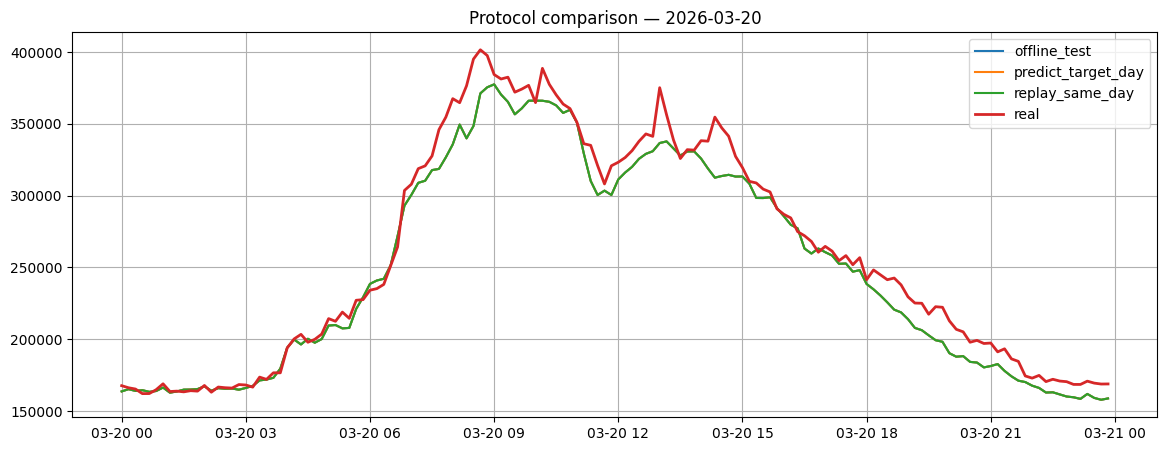

In [ ]:
def plot_protocol_comparison(target_date: str):
    fig, ax = plt.subplots(figsize=(14, 5))

    if not offline_day_df.empty and "Ptot_TOTAL_Forecast" in offline_day_df.columns:
        ax.plot(offline_day_df["Date"], offline_day_df["Ptot_TOTAL_Forecast"], label="offline_test")
    if not predict_day_df.empty and "Ptot_TOTAL_Forecast" in predict_day_df.columns:
        ax.plot(predict_day_df["Date"], predict_day_df["Ptot_TOTAL_Forecast"], label="predict_target_day")
    if not replay_day_df.empty and "Ptot_TOTAL_Forecast" in replay_day_df.columns:
        ax.plot(replay_day_df["Date"], replay_day_df["Ptot_TOTAL_Forecast"], label="replay_same_day")
    if not replay_day_df.empty and "Ptot_TOTAL_Real" in replay_day_df.columns:
        ax.plot(replay_day_df["Date"], replay_day_df["Ptot_TOTAL_Real"], label="real", linewidth=2)

    ax.set_title(f"Protocol comparison — {target_date}")
    ax.legend()
    ax.grid(True)
    plt.show()

plot_protocol_comparison(TARGET_DATE)


## Analyse détaillée d'un ou plusieurs jours

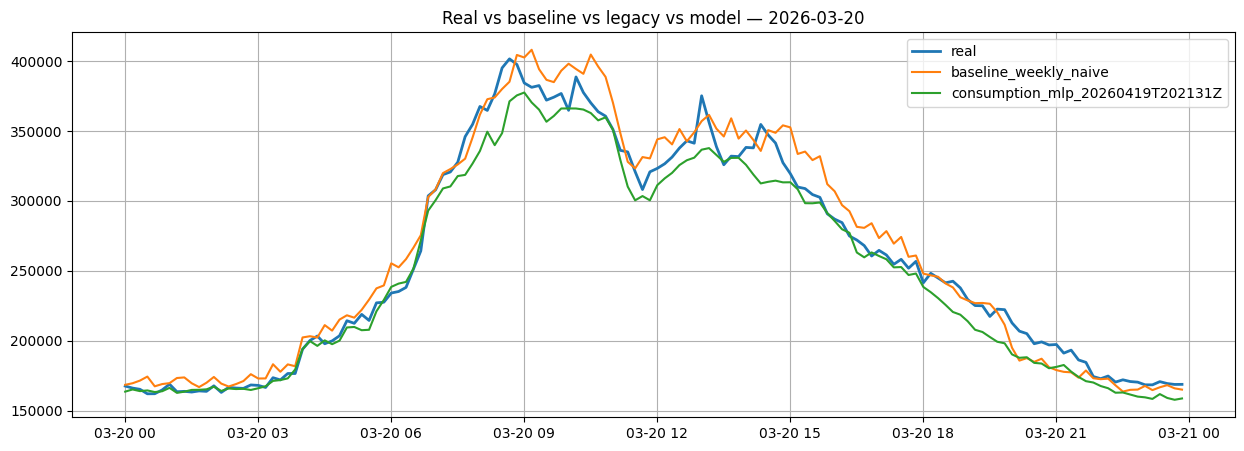

/tmp/ipykernel_32140/434293395.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


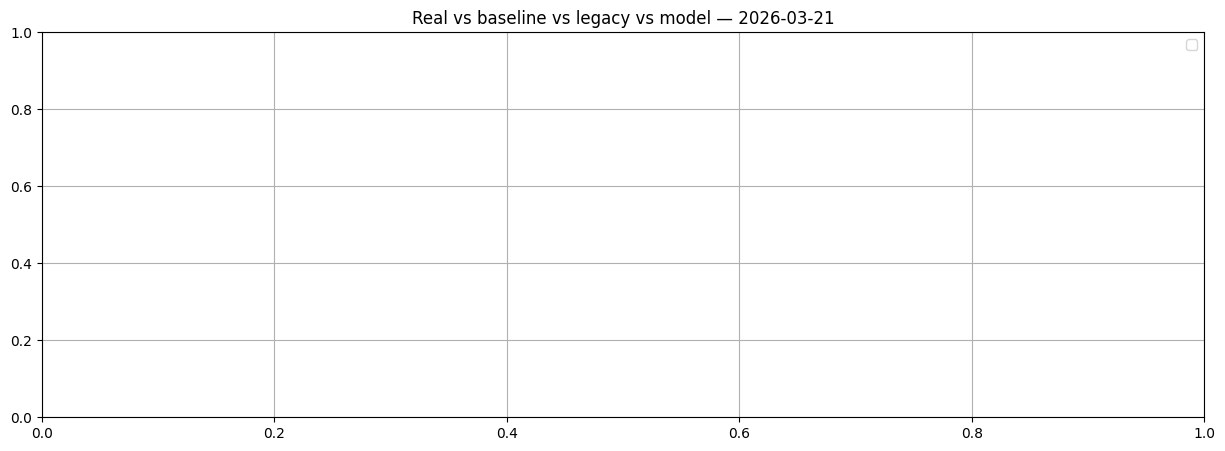

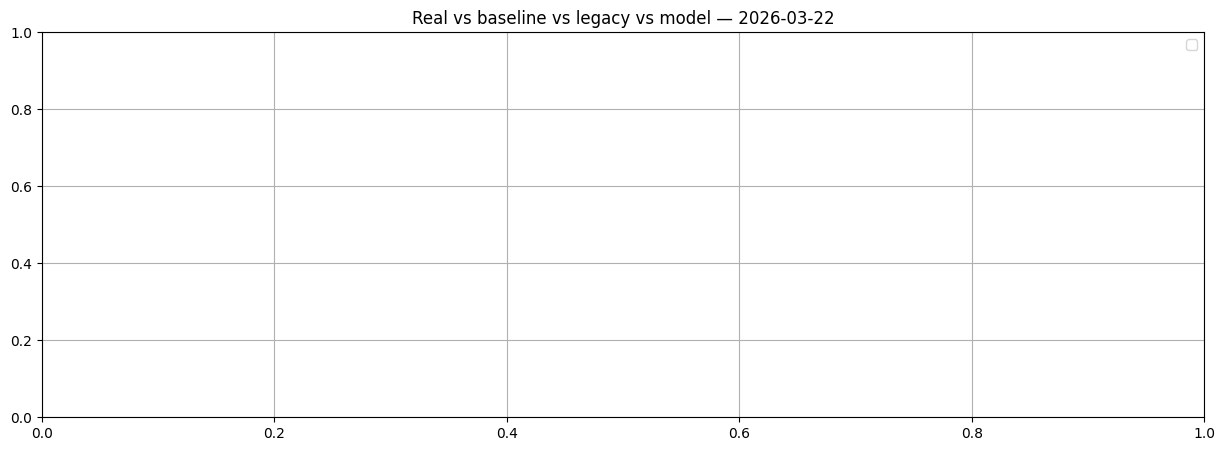

In [ ]:
def compute_legacy_total(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    forecast_cols = [
        "Ptot_HA_Forecast",
        "Ptot_HEI_13RT_Forecast",
        "Ptot_HEI_5RNS_Forecast",
        "Ptot_RIZOMM_Forecast",
    ]
    available = [c for c in forecast_cols if c in out.columns]
    if available:
        out["OldLegacy_TOTAL_Forecast"] = out[available].sum(axis=1)
    return out

legacy_df = compute_legacy_total(legacy_df)

def plot_day_overlay(day: str):
    fig, ax = plt.subplots(figsize=(15, 5))

    r = slice_day(replay_detail_df, day)
    o = slice_day(offline_backtest_df, day)
    l = slice_day(legacy_df, day)

    if not r.empty and "Ptot_TOTAL_Real" in r.columns:
        ax.plot(r["Date"], r["Ptot_TOTAL_Real"], label="real", linewidth=2)
    elif not o.empty and "tot" in o.columns:
        ax.plot(o["Date"], o["tot"], label="real", linewidth=2)

    if not r.empty and "Baseline_Weekly_Naive" in r.columns:
        ax.plot(r["Date"], r["Baseline_Weekly_Naive"], label="baseline_weekly_naive")
    elif not o.empty and "Baseline_Weekly_Naive" in o.columns:
        ax.plot(o["Date"], o["Baseline_Weekly_Naive"], label="baseline_weekly_naive")

    if not l.empty and "OldLegacy_TOTAL_Forecast" in l.columns:
        ax.plot(l["Date"], l["OldLegacy_TOTAL_Forecast"], label="legacy_forecast")

    if not r.empty and "Ptot_TOTAL_Forecast" in r.columns:
        model_label = SELECTED_MODEL_NAME or ACTIVE_RUN_ID or "model"
        ax.plot(r["Date"], r["Ptot_TOTAL_Forecast"], label=model_label)

    ax.set_title(f"Real vs baseline vs legacy vs model — {day}")
    ax.legend()
    ax.grid(True)
    plt.show()

for day in PLOT_SAMPLE_DAYS:
    plot_day_overlay(day)


## Erreurs sur le replay

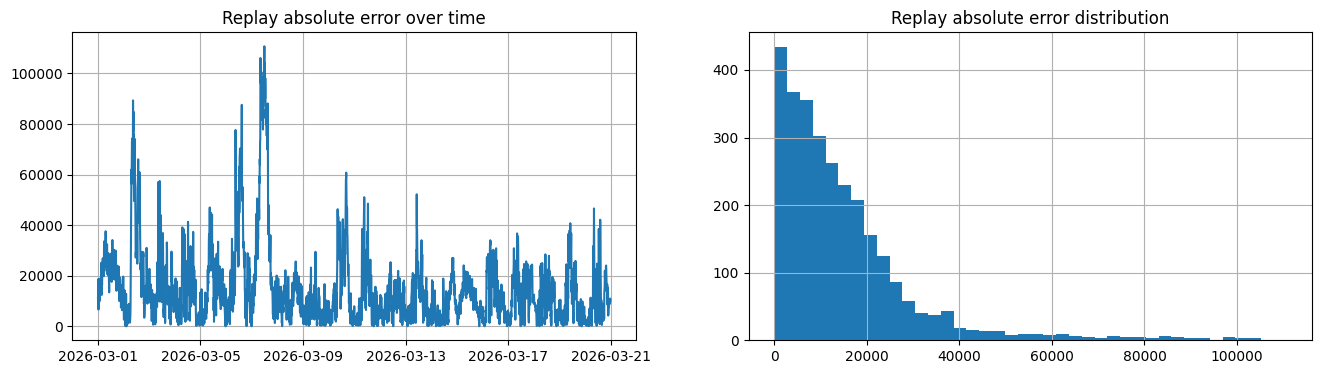

In [ ]:
if not replay_detail_df.empty and {"Ptot_TOTAL_Forecast", "Ptot_TOTAL_Real"}.issubset(replay_detail_df.columns):
    replay_detail_df = replay_detail_df.copy()
    replay_detail_df["abs_error"] = (replay_detail_df["Ptot_TOTAL_Forecast"] - replay_detail_df["Ptot_TOTAL_Real"]).abs()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    axes[0].plot(replay_detail_df["Date"], replay_detail_df["abs_error"])
    axes[0].set_title("Replay absolute error over time")
    axes[0].grid(True)

    axes[1].hist(replay_detail_df["abs_error"].dropna(), bins=40)
    axes[1].set_title("Replay absolute error distribution")
    axes[1].grid(True)

    plt.show()


## Classement final des modèles

,requested_model_run_id,config_name,MAE,RMSE,MAPE%,InTolerance%,n_forecasted_days,n_skipped_days
0,consumption_mlp_20260419T202131Z,mlp_strict_day_ahead_baseline.yaml,14974.975629,21607.247800,5.783302,25.729167,20,11
1,consumption_mlp_20260419T202225Z,mlp_strict_day_ahead_cyclical_weather_basic.yaml,16830.976047,22447.634296,6.504480,16.562500,20,11
2,consumption_mlp_20260419T202255Z,mlp_strict_day_ahead_cyclical_weather_shifted_...,17888.543023,23226.883022,7.214618,12.256944,20,11
3,consumption_mlp_20260419T202200Z,mlp_strict_day_ahead_weather_basic.yaml,19495.827718,25312.196212,7.699816,11.111111,20,11


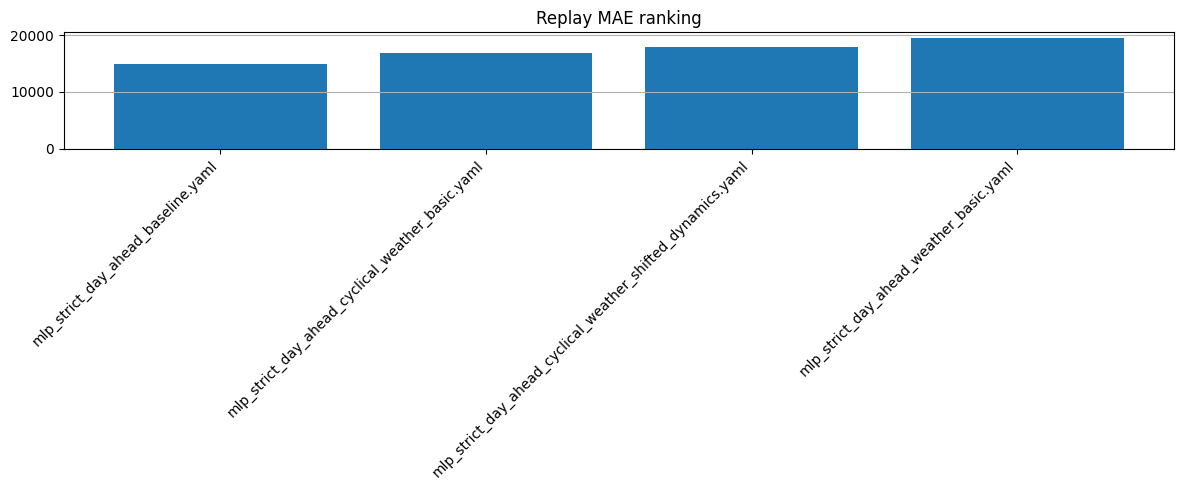

In [ ]:
final_ranking_df = leaderboard_df.copy()

if not final_ranking_df.empty:
    rank_cols = [c for c in ["requested_model_run_id", "config_name", "MAE", "RMSE", "MAPE%", "InTolerance%", "n_forecasted_days", "n_skipped_days"] if c in final_ranking_df.columns]
    display(final_ranking_df[rank_cols])

    plt.figure(figsize=(12, 5))
    x = range(len(final_ranking_df))
    labels = final_ranking_df["config_name"] if "config_name" in final_ranking_df.columns else final_ranking_df["requested_model_run_id"]
    mae_vals = final_ranking_df["MAE"] if "MAE" in final_ranking_df.columns else None
    if mae_vals is not None:
        plt.bar(x, mae_vals)
        plt.xticks(list(x), labels, rotation=45, ha="right")
        plt.title("Replay MAE ranking")
        plt.grid(True, axis="y")
        plt.tight_layout()
        plt.show()


## Promotion du meilleur modèle

In [ ]:
winner_run_id = None
if not leaderboard_df.empty and "requested_model_run_id" in leaderboard_df.columns:
    winner_run_id = str(leaderboard_df.iloc[0]["requested_model_run_id"])

print("winner_run_id:", winner_run_id)

if RUN_PROMOTE and PROMOTE_WINNER and winner_run_id:
    cmd = [
        "python",
        "scripts/promote_consumption_run.py",
        "--run-id",
        winner_run_id,
    ]
    completed = run_cli(cmd, cwd=ROOT)

winner_run_id: consumption_mlp_20260419T202131Z


## Notes finales

Ce notebook doit rester :

- **CLI-first**
- **replay-first**
- **strict-day-ahead-first**

À garder en tête :
- `offline_test_*` = diagnostic
- `replay` = benchmark officiel
- `predict_target_day` = démo de la chaîne runtime
- `intraday_reforecast` = hors benchmark officiel tant que non normalisé
